# Supplementary Figure 4

Computational panels A–D.

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = "retina"
import os
from pathlib import Path

# Locate the repository whether the notebook is run from the repo root or notebook/.
_start = Path.cwd().resolve()
ROOT = next(
    candidate
    for candidate in (_start, *_start.parents)
    if (candidate / "environment.yml").is_file()
)

# Override this environment variable when the shared data directory is mounted elsewhere.
DATA_ROOT = Path(
    os.environ.get("BIOAGENTS_DATA_ROOT", "/gpfs/group/jin/asun/bioagents/data")
)
DEG_PATH = DATA_ROOT / "wilcoxon_de_results_group_name_final_data_no_multi_guide_cells.parquet"
REPORTS_PATH = DATA_ROOT / "perturbai_reports" / "reports" / "html"


## Supplementary Figure 4A — finding breadth

Cited and additional findings grouped by claim and finding type.

Supplementary Figure 4A: 531 unique gene × finding records = 210 cited + 321 additional.
The 12 overlapping source-study topic groups contain 352 additional-finding instances and are not additive.


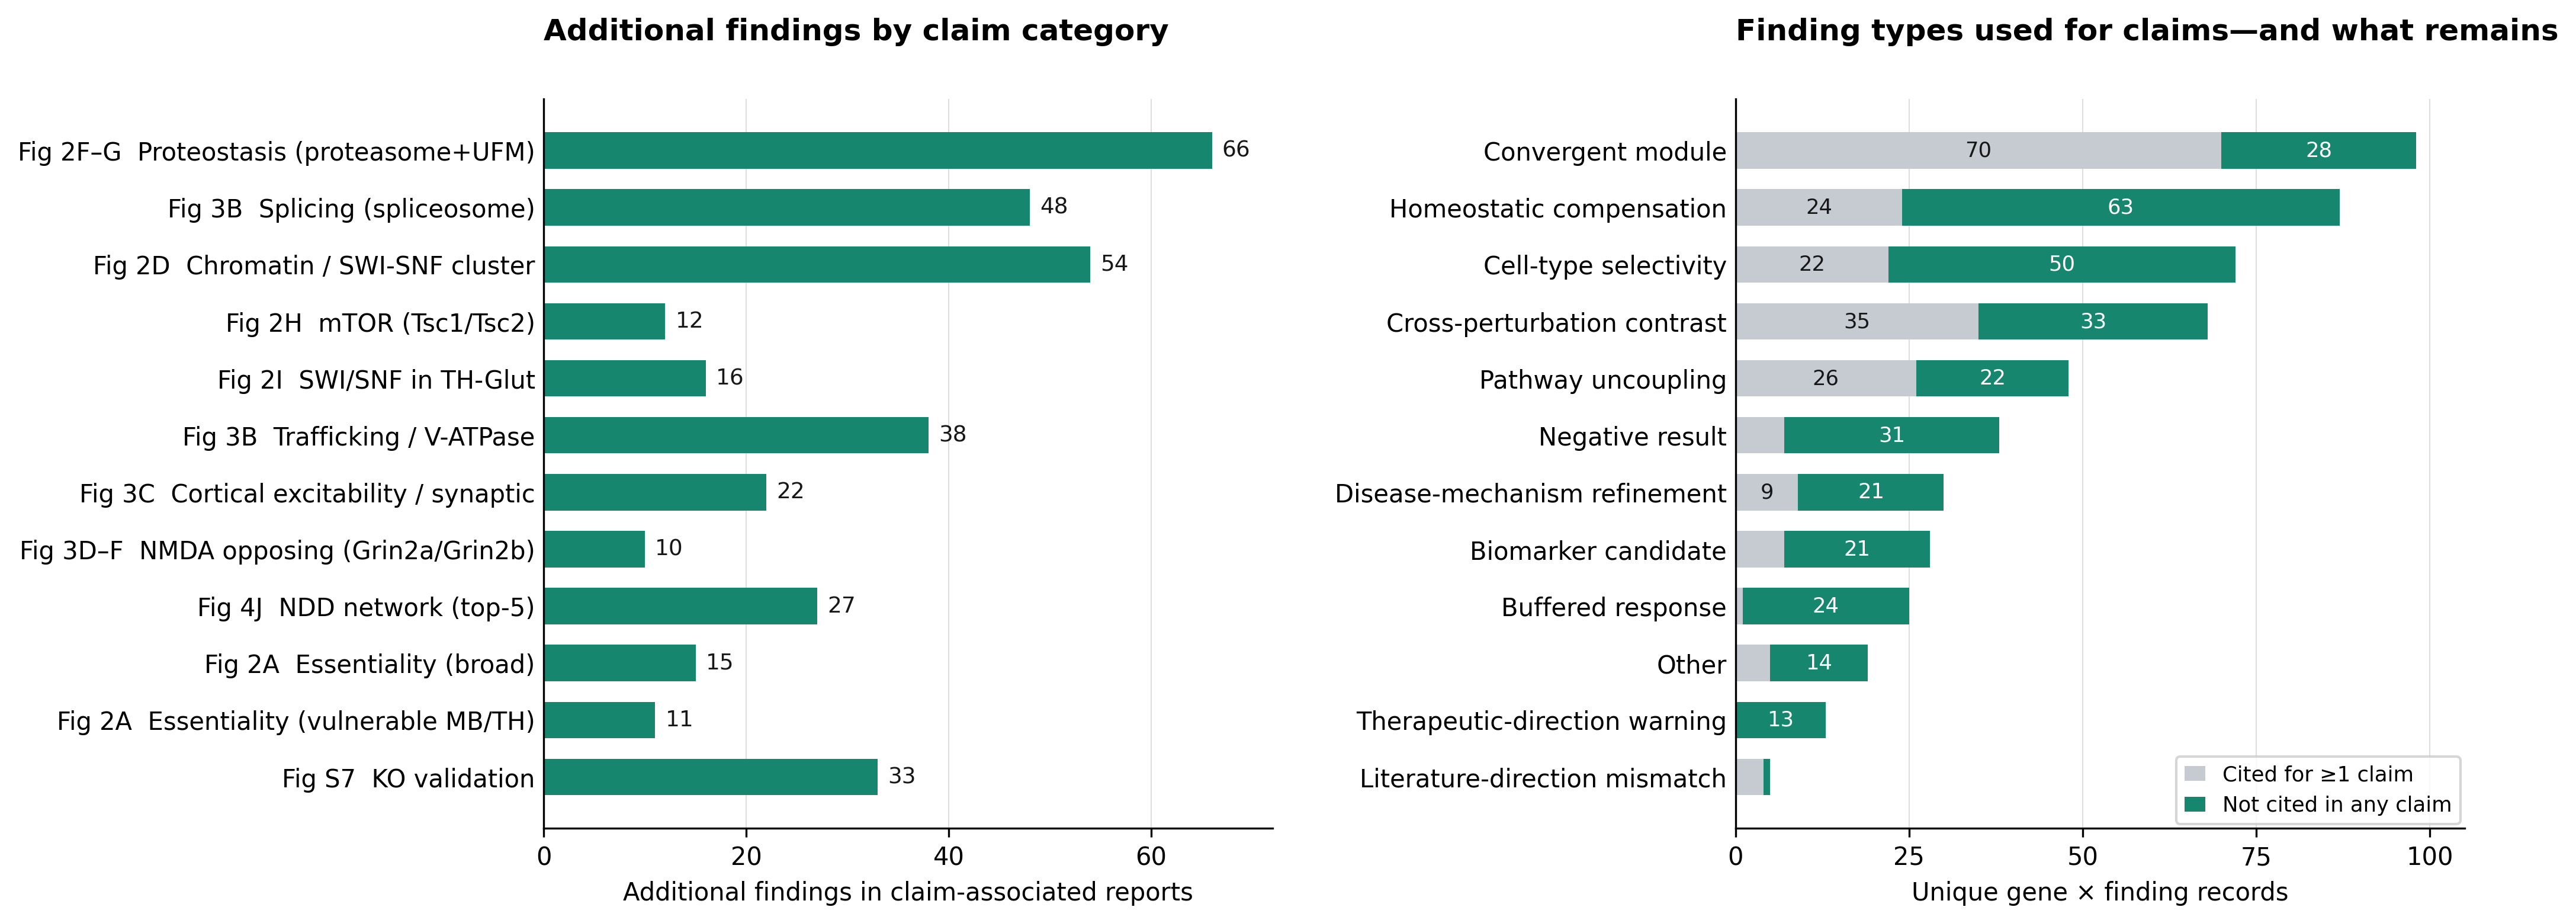

In [2]:
from collections import Counter, defaultdict
import json
import re

import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 150, "savefig.dpi": 300})
from matplotlib.patches import Patch
import pandas as pd

FIGS4A_DIR = ROOT / "src/manuscript_figures/figS4/a"
CLAIM_PATH = FIGS4A_DIR / "july_claim_findings.csv"
JULY_REPORTS_PATH = DATA_ROOT / "PerturbAI_findings_260713_rosalind_j768_reports_2045.jsonl"

claims = pd.read_csv(CLAIM_PATH, dtype=str)
CLAIM_ORDER = ("2a", "2b", "2c", "2d", "3c", "4b", "4e", "5", "7", "1a", "1b", "8")
EXPECTED_FLAGS = Counter({"M": 35, "R": 13, "P": 9, "D": 14})
assert claims.columns.tolist() == [
    "headline_id", "paper_figure", "headline", "gene", "july_verdict", "july_finding_ids"
]
assert len(claims) == 71
assert claims[["headline_id", "gene"]].drop_duplicates().shape[0] == 71
assert claims.gene.nunique() == 62
assert tuple(claims.headline_id.drop_duplicates()) == CLAIM_ORDER
assert Counter(claims.july_verdict) == EXPECTED_FLAGS

needed_genes = set(claims.gene)
reports = {}
with JULY_REPORTS_PATH.open(encoding="utf-8") as handle:
    for line in handle:
        if not line.strip():
            continue
        row = json.loads(line)
        gene = str(row.get("gene_target") or "").strip()
        if gene not in needed_genes:
            continue
        report = next(
            (
                row.get(field)
                for field in ("report", "final_report", "scientist_report")
                if isinstance(row.get(field), str) and row[field].strip()
            ),
            None,
        )
        if report is None:
            raise ValueError(f"{gene}: no report text")
        if gene in reports:
            raise ValueError(f"{gene}: duplicate report")
        reports[gene] = report
assert set(reports) == needed_genes

findings_block = re.compile(
    r"^#{1,6}\s+Biological Findings JSONL\s*$"
    r".*?^\u0060\u0060\u0060jsonl\s*$\n(?P<body>.*?)\n^\u0060\u0060\u0060\s*$",
    re.IGNORECASE | re.MULTILINE | re.DOTALL,
)
findings_by_gene = {}
for gene, report in reports.items():
    match = findings_block.search(report)
    if match is None:
        raise ValueError(f"{gene}: Biological Findings JSONL block not found")
    parsed = {}
    for line in match.group("body").splitlines():
        if not line.strip():
            continue
        finding = json.loads(line)
        finding_id = str(finding.get("finding_id") or "")
        if not re.fullmatch(r"F\d{3}", finding_id):
            raise ValueError(f"{gene}: invalid finding ID {finding_id!r}")
        if finding_id in parsed:
            raise ValueError(f"{gene}: duplicate finding {finding_id}")
        parsed[finding_id] = finding
    findings_by_gene[gene] = parsed

cited_ids = defaultdict(set)
for row in claims.itertuples(index=False):
    cited_ids[row.gene].update(fid for fid in row.july_finding_ids.split(";") if fid)

all_pairs = {
    (gene, finding_id)
    for gene, findings in findings_by_gene.items()
    for finding_id in findings
}
cited_pairs = {
    (gene, finding_id)
    for gene, finding_ids in cited_ids.items()
    for finding_id in finding_ids
}
assert cited_pairs <= all_pairs
additional_pairs = all_pairs - cited_pairs

inventory_rows = []
for gene, findings in findings_by_gene.items():
    for finding_id, finding in findings.items():
        pair = (gene, finding_id)
        inventory_rows.append(
            {
                "gene": gene,
                "finding_id": finding_id,
                "finding_type": str(finding["finding_type"]),
                "status": "Cited for ≥1 claim" if pair in cited_pairs else "Not cited in any claim",
            }
        )
inventory = pd.DataFrame(inventory_rows)

TYPE_ORDER = (
    "convergent_module",
    "homeostatic_compensation",
    "cell_type_selectivity",
    "cross_perturbation_contrast",
    "pathway_uncoupling",
    "negative_result",
    "disease_mechanism_refinement",
    "biomarker_candidate",
    "buffered_response",
    "other",
    "therapeutic_direction_warning",
    "literature_direction_mismatch",
)
TYPE_LABELS = {
    "convergent_module": "Convergent module",
    "homeostatic_compensation": "Homeostatic compensation",
    "cell_type_selectivity": "Cell-type selectivity",
    "cross_perturbation_contrast": "Cross-perturbation contrast",
    "pathway_uncoupling": "Pathway uncoupling",
    "negative_result": "Negative result",
    "disease_mechanism_refinement": "Disease-mechanism refinement",
    "biomarker_candidate": "Biomarker candidate",
    "buffered_response": "Buffered response",
    "other": "Other",
    "therapeutic_direction_warning": "Therapeutic-direction warning",
    "literature_direction_mismatch": "Literature-direction mismatch",
}
assert set(inventory.finding_type) == set(TYPE_ORDER)
assert (len(all_pairs), len(cited_pairs), len(additional_pairs)) == (531, 210, 321)

claim_labels = {}
claim_additional = {}
for headline_id in CLAIM_ORDER:
    group = claims[claims.headline_id.eq(headline_id)]
    metadata = group[["paper_figure", "headline"]].drop_duplicates()
    assert len(metadata) == 1
    paper_figure, headline = metadata.iloc[0]
    claim_labels[headline_id] = f"{paper_figure}  {headline}"
    claim_genes = set(group.gene)
    claim_additional[headline_id] = sum(gene in claim_genes for gene, _ in additional_pairs)
assert sum(claim_additional.values()) == 352

type_counts = (
    inventory.groupby(["finding_type", "status"])
    .size()
    .unstack(fill_value=0)
    .reindex(TYPE_ORDER)
)
print(
    f"Supplementary Figure 4A: {len(inventory)} unique gene × finding records = "
    f"{len(cited_pairs)} cited + {len(additional_pairs)} additional."
)
print(
    "The 12 overlapping source-study topic groups contain "
    f"{sum(claim_additional.values())} additional-finding instances and are not additive."
)

colors = {"cited": "#c5cbd1", "additional": "#16866f", "ink": "#171717", "muted": "#5c6063"}
with plt.rc_context({"font.family": "DejaVu Sans", "pdf.fonttype": 42, "svg.fonttype": "none"}):
    fig, axes = plt.subplots(1, 2, figsize=(14.0, 7.0))
    ax = axes[0]
    y = range(len(CLAIM_ORDER))
    values = [claim_additional[h] for h in CLAIM_ORDER]
    ax.barh(list(y), values, height=.64, color=colors["additional"], linewidth=0, zorder=2)
    for yi, value in zip(y, values):
        ax.text(value + 1, yi, str(value), ha="left", va="center", fontsize=9, color=colors["ink"])
    ax.set_yticks(list(y), [claim_labels[h] for h in CLAIM_ORDER])
    ax.invert_yaxis()
    ax.set_xlim(0, 72)
    ax.set_xticks([0, 20, 40, 60])
    ax.set_xlabel("Additional findings in claim-associated reports")
    ax.set_title("Additional findings by claim category", loc="left", fontsize=12, fontweight="bold", pad=24)
    ax.grid(axis="x", color="#dedede", linewidth=.5, zorder=0)
    ax.tick_params(axis="y", length=0)
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_box_aspect(1)

    ax = axes[1]
    y = range(len(TYPE_ORDER))
    cited = type_counts["Cited for ≥1 claim"].tolist()
    additional = type_counts["Not cited in any claim"].tolist()
    ax.barh(list(y), cited, height=.64, color=colors["cited"], linewidth=0, zorder=2)
    ax.barh(list(y), additional, left=cited, height=.64, color=colors["additional"], linewidth=0, zorder=2)
    for yi, (n_cited, n_additional) in enumerate(zip(cited, additional)):
        if n_cited >= 8:
            ax.text(n_cited / 2, yi, str(n_cited), ha="center", va="center", fontsize=8.5, color=colors["ink"])
        if n_additional >= 8:
            ax.text(n_cited + n_additional / 2, yi, str(n_additional), ha="center", va="center", fontsize=8.5, color="white")
    ax.set_yticks(list(y), [TYPE_LABELS[t] for t in TYPE_ORDER])
    ax.invert_yaxis()
    ax.set_xlim(0, 105)
    ax.set_xticks([0, 25, 50, 75, 100])
    ax.set_xlabel("Unique gene × finding records")
    ax.set_title("Finding types used for claims—and what remains", loc="left", fontsize=12, fontweight="bold", pad=24)
    ax.legend(
        handles=[
            Patch(facecolor=colors["cited"], label="Cited for ≥1 claim"),
            Patch(facecolor=colors["additional"], label="Not cited in any claim"),
        ],
        loc="lower right", fontsize=8.5, handlelength=1, borderaxespad=.2,
    )
    ax.grid(axis="x", color="#dedede", linewidth=.5, zorder=0)
    ax.tick_params(axis="y", length=0)
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_box_aspect(1)

    fig.tight_layout(pad=.8, w_pad=2.5)
    fig.savefig(FIGS4A_DIR / "S4A_additional_finding_breadth.pdf", bbox_inches="tight", pad_inches=.08)
    plt.show()

## Supplementary Figure 4B — Tpr/Thoc2 RNA-export neighborhoods

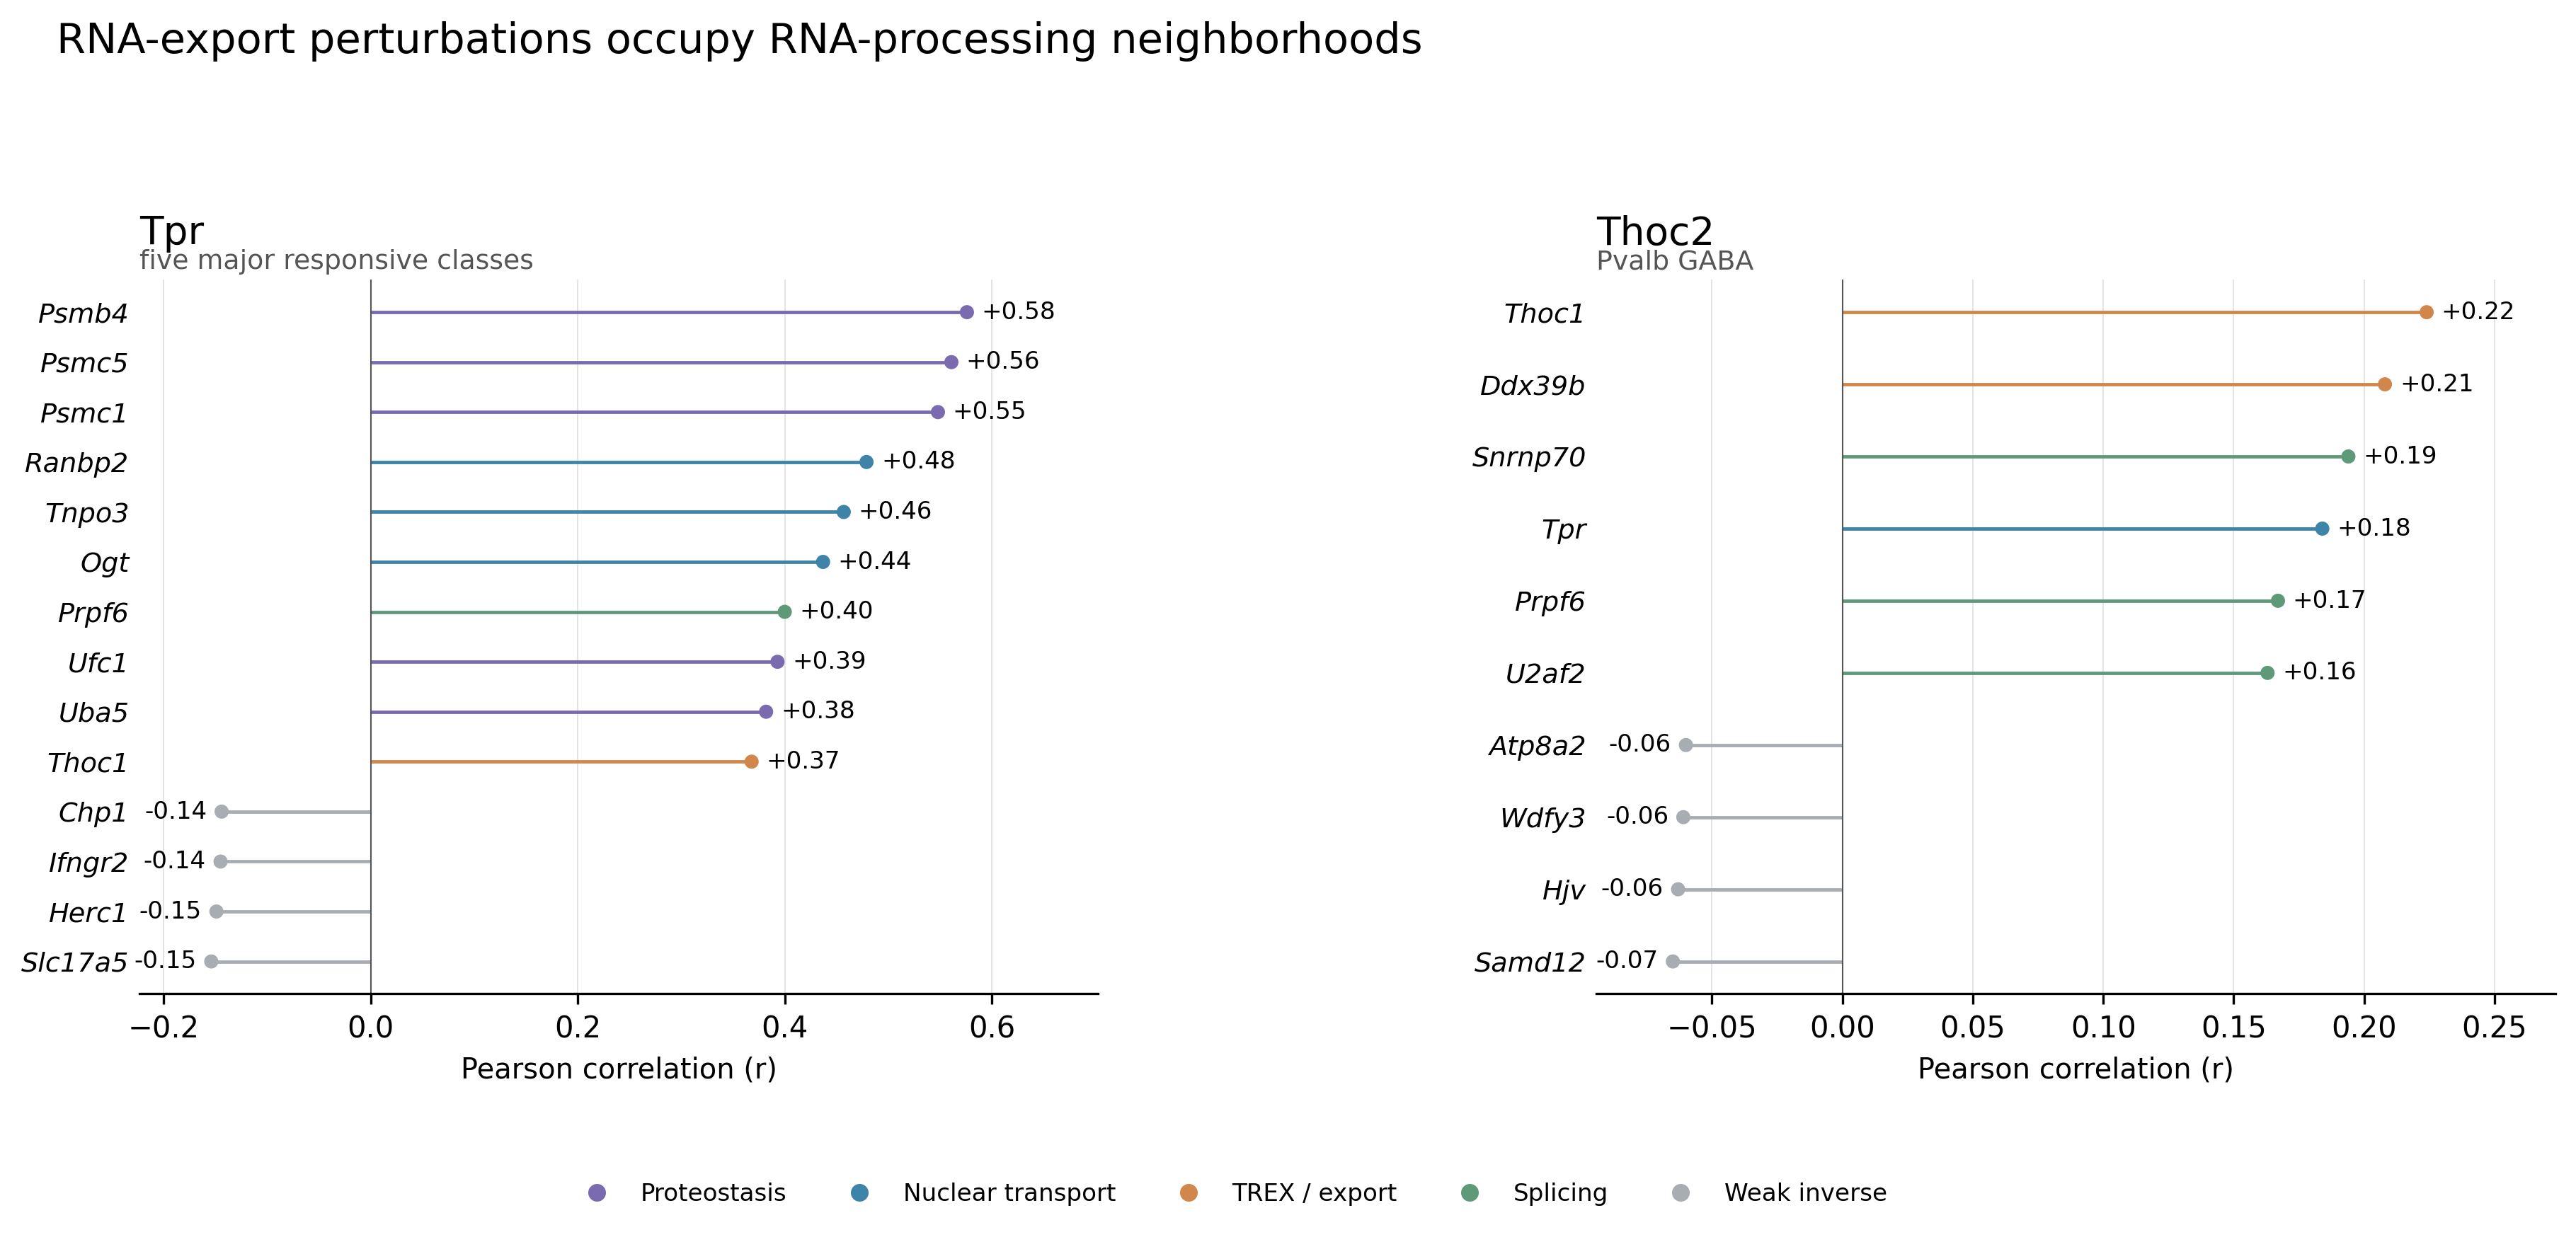

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

tpr = pd.DataFrame([
    ("Psmb4", .576, "Proteostasis"), ("Psmc5", .561, "Proteostasis"), ("Psmc1", .548, "Proteostasis"),
    ("Ranbp2", .479, "Nuclear transport"), ("Tnpo3", .457, "Nuclear transport"), ("Ogt", .437, "Nuclear transport"),
    ("Prpf6", .400, "Splicing"), ("Ufc1", .393, "Proteostasis"), ("Uba5", .382, "Proteostasis"),
    ("Thoc1", .368, "TREX / export"), ("Slc17a5", -.154, "Weak inverse"), ("Herc1", -.149, "Weak inverse"),
    ("Ifngr2", -.145, "Weak inverse"), ("Chp1", -.144, "Weak inverse")], columns=["neighbor", "r", "process"])
thoc2 = pd.DataFrame([
    ("Thoc1", .224, "TREX / export"), ("Ddx39b", .208, "TREX / export"), ("Snrnp70", .194, "Splicing"),
    ("Tpr", .184, "Nuclear transport"), ("Prpf6", .167, "Splicing"), ("U2af2", .163, "Splicing"),
    ("Atp8a2", -.060, "Weak inverse"), ("Wdfy3", -.061, "Weak inverse"), ("Hjv", -.063, "Weak inverse"),
    ("Samd12", -.065, "Weak inverse")], columns=["neighbor", "r", "process"])
colors = {"Proteostasis": "#7A6BB0", "Nuclear transport": "#3E83A8", "TREX / export": "#D1874B", "Splicing": "#5F9A78", "Weak inverse": "#A7ADB2"}
fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.8), gridspec_kw={"wspace": .52})
for ax, data, title, subtitle in [(axes[0], tpr, "Tpr", "five major responsive classes"), (axes[1], thoc2, "Thoc2", "Pvalb GABA")]:
    data = data.sort_values("r").reset_index(drop=True); y = range(len(data)); color = [colors[x] for x in data.process]
    ax.hlines(y, 0, data.r, color=color, lw=1.15, zorder=2); ax.scatter(data.r, y, s=23, color=color, edgecolor="none", zorder=3)
    ax.set_yticks(list(y), data.neighbor, fontstyle="italic", fontsize=9.2)
    for yi, row in data.iterrows():
        ax.annotate(f"{row.r:+.2f}", (row.r, yi), xytext=(5 if row.r >= 0 else -5, 0), textcoords="offset points",
                    ha="left" if row.r >= 0 else "right", va="center", fontsize=8.2)
    ax.axvline(0, color="#555555", lw=.5); ax.set_xlim(min(data.r) * 1.45, max(data.r) * 1.22)
    ax.set_title(title, loc="left", fontsize=13.2, pad=12); ax.text(0, 1.015, subtitle, transform=ax.transAxes, fontsize=9.1, color="#555555")
    ax.set_xlabel("Pearson correlation (r)", fontsize=9.6); ax.grid(axis="x", color="#E3E3E3", lw=.45)
    ax.spines[["top", "right", "left"]].set_visible(False); ax.tick_params(axis="y", length=0)
handles = [plt.Line2D([0], [0], marker="o", ls="", ms=5, color=value, label=key) for key, value in colors.items()]
fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(.5, -.01), ncol=5, frameon=False, fontsize=8.2)
fig.suptitle("RNA-export perturbations occupy RNA-processing neighborhoods", x=.075, y=.97, ha="left", fontsize=14.2)
fig.subplots_adjust(left=.105, right=.98, bottom=.18, top=.76)
plt.show()

## Supplementary Figure 4C — mitochondrial-transcript volcano plots

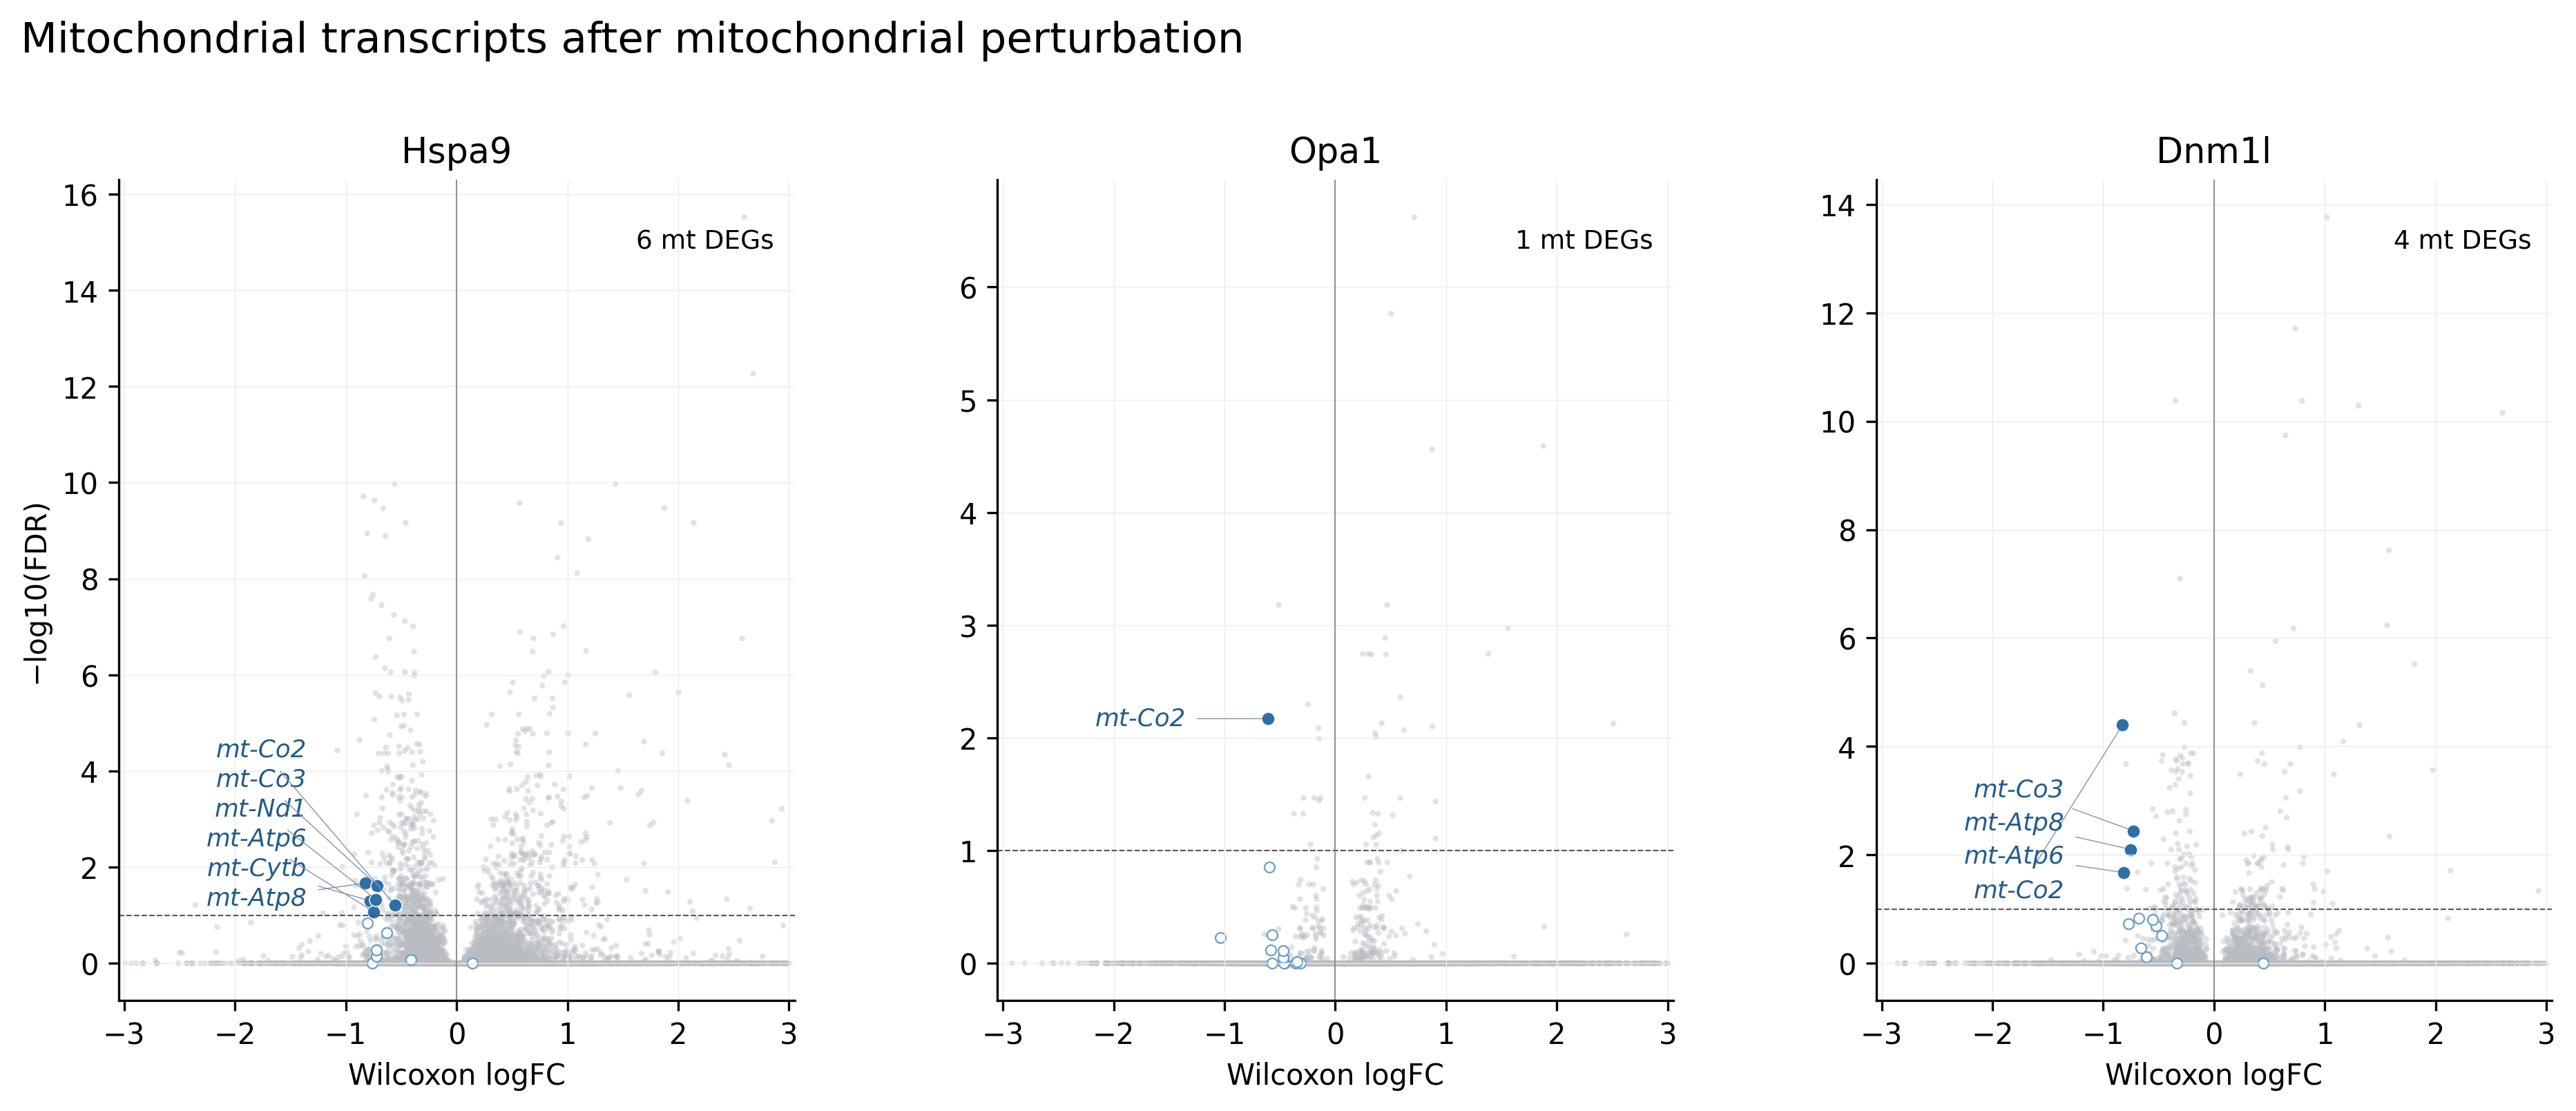

In [4]:
import numpy as np

volcano_path = ROOT / "src/manuscript_figures/figS4/c/R06_selected_revision_mito_targets_TH_Glut_volcano_values.csv"
d = pd.read_csv(volcano_path)
targets = ["Hspa9", "Opa1", "Dnm1l"]
fig, axes = plt.subplots(1, 3, figsize=(13.5, 5.5), gridspec_kw={"wspace": .30})
for ax, target in zip(axes, targets):
    z = d[d.gene_target.eq(target)].copy(); z["mlog10FDR"] = -np.log10(z.FDR.clip(lower=1e-300))
    bg = z[~z.is_mt]; mt0 = z[z.is_mt & ~z.sig]; mts = z[z.is_mt & z.sig].sort_values("logFC")
    ax.scatter(bg.logFC, bg.mlog10FDR, s=4, color="#B9BDC1", alpha=.43, edgecolor="none")
    ax.scatter(mt0.logFC, mt0.mlog10FDR, s=13, facecolor="white", edgecolor="#6EA0C7", linewidth=.55)
    ax.scatter(mts.logFC, mts.mlog10FDR, s=21, color="#2F6FA5", edgecolor="white", linewidth=.35)
    ax.axhline(-np.log10(.1), color="#555555", lw=.5, ls="--"); ax.axvline(0, color="#777777", lw=.38)
    if len(mts):
        label_y = mts.mlog10FDR.median() + (np.arange(len(mts)) - (len(mts) - 1) / 2) * .62
        if label_y.min() < 1.35: label_y += 1.35 - label_y.min()
        for (_, row), yy in zip(mts.iterrows(), label_y):
            ax.annotate(row.gene, (row.logFC, row.mlog10FDR), xytext=(-1.35, yy), fontsize=8.6, fontstyle="italic",
                        ha="right", va="center", color="#245C8A", arrowprops=dict(arrowstyle="-", lw=.33, color="#8194A4"))
    ax.set_xlim(-3.05, 3.05); ax.set_title(target, fontsize=12.2); ax.text(.97, .94, f"{len(mts)} mt DEGs", transform=ax.transAxes, ha="right", va="top", fontsize=9)
    ax.grid(color="#ECECEC", lw=.32); ax.spines[["top", "right"]].set_visible(False); ax.set_xlabel("Wilcoxon logFC", fontsize=10)
axes[0].set_ylabel("−log10(FDR)", fontsize=10)
fig.suptitle("Mitochondrial transcripts after mitochondrial perturbation", x=.075, y=.98, ha="left", fontsize=14.7)
fig.subplots_adjust(left=.11, right=.98, bottom=.12, top=.84)
plt.show()

## Supplementary Figure 4D — biological themes across ASD reports

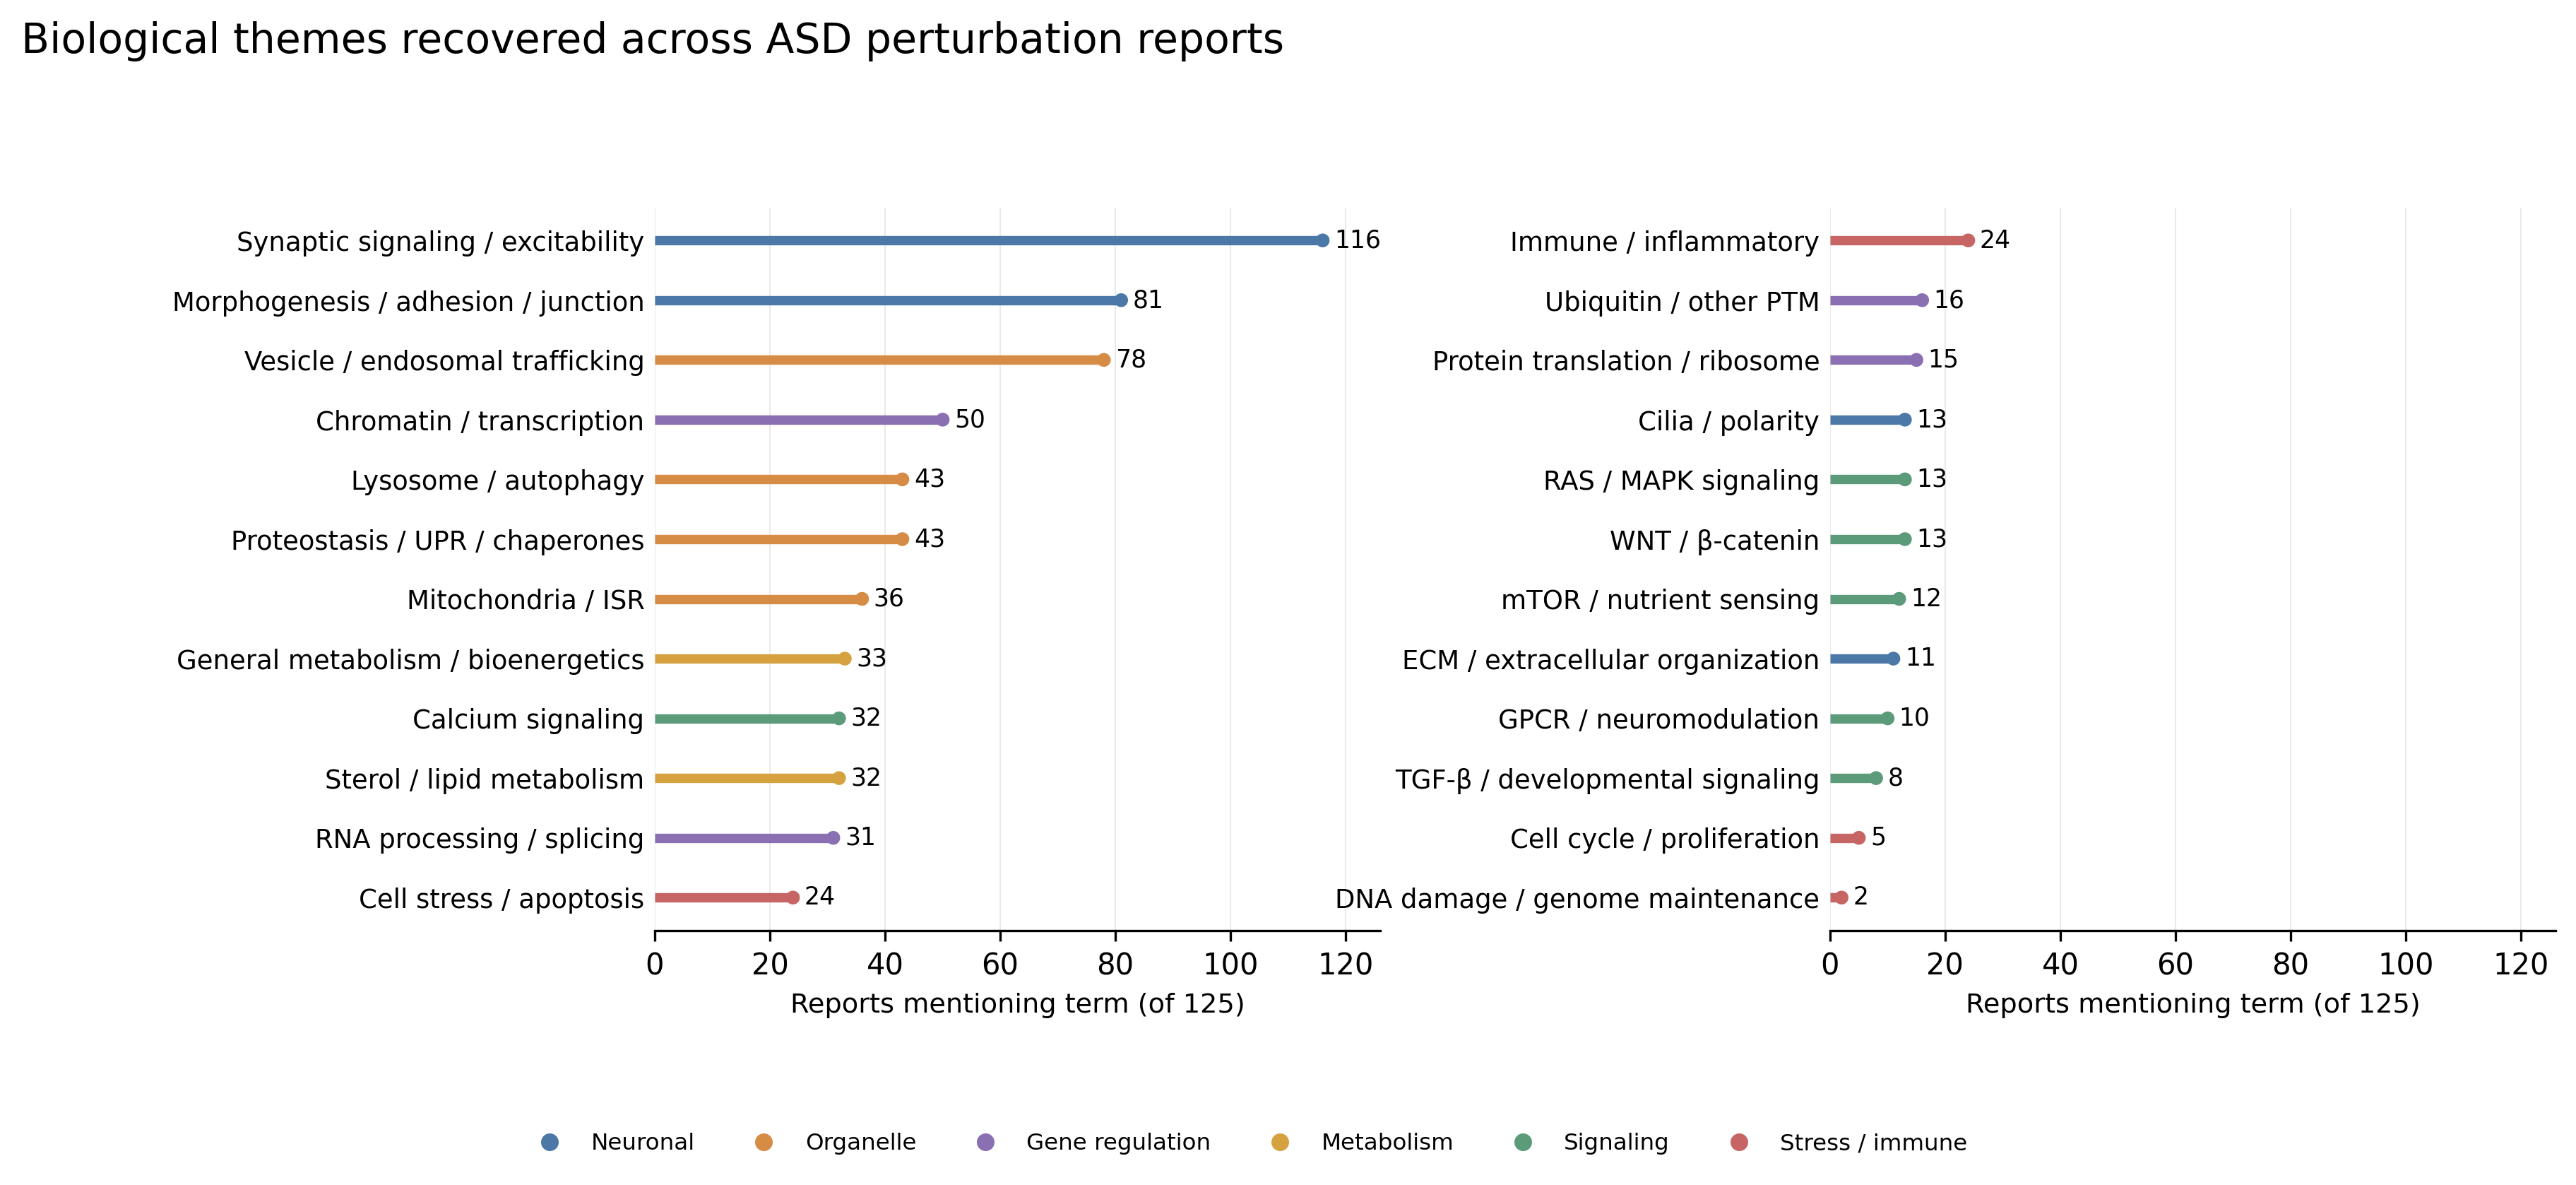

In [5]:
terms_path = ROOT / "src/manuscript_figures/figS4/d/N13_ASD125_all_report_biological_terms.csv"
d = pd.read_csv(terms_path)
palette = {"Neuronal": "#4C78A8", "Organelle": "#D68C45", "Gene regulation": "#8A6FB3", "Metabolism": "#D6A23F", "Signaling": "#5C9B79", "Stress / immune": "#C76565"}
fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.5), gridspec_kw={"wspace": .62})
for ax, subset in zip(axes, [d.iloc[:12].iloc[::-1], d.iloc[12:].iloc[::-1]]):
    y = range(len(subset)); color = [palette[x] for x in subset.family]
    ax.hlines(y, 0, subset.n_reports, color=color, lw=3.2); ax.scatter(subset.n_reports, y, s=22, color=color, edgecolor="none")
    ax.set_yticks(list(y), subset.term, fontsize=8.9)
    for i, (_, row) in enumerate(subset.iterrows()): ax.text(row.n_reports + 2, i, str(row.n_reports), va="center", fontsize=8.3)
    ax.set_xlim(0, 126); ax.grid(axis="x", color="#E5E5E5", lw=.4); ax.spines[["top", "right", "left"]].set_visible(False)
    ax.tick_params(axis="y", length=0); ax.set_xlabel("Reports mentioning term (of 125)", fontsize=9.2)
handles = [plt.Line2D([0], [0], marker="o", ls="", ms=5, color=value, label=key) for key, value in palette.items()]
fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(.5, -.01), ncol=6, frameon=False, fontsize=7.8)
fig.suptitle("Biological themes recovered across ASD perturbation reports", x=.055, y=.98, ha="left", fontsize=14)
fig.subplots_adjust(left=.285, right=.975, bottom=.20, top=.82)
plt.show()